In [13]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()


Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


1. Types of data & variables

1A. NUMERICAL vs CATEGORICAL COLUMNS

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

df = sns.load_dataset('tips')

print('Loaded tips dataset:', df.shape)
df.head()
print(df.dtypes)

numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()

print('\nNumerical  :', numerical)
print('Categorical:', categorical)


Loaded tips dataset: (244, 7)
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


1B. WHICH STATISTIC FITS WHICH TYPE

In [15]:
print('Mean total_bill:', round(df['total_bill'].mean(), 2))


print('Day value counts:')
print(df['day'].value_counts())


Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


LAB EXERCISE 1 — Classify the columns

1. Numerical vs categorical columns


In [16]:
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()

print('Numerical  :', numerical)
print('Categorical:', categorical)


Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


2. Mean of a numerical column (tip)

In [17]:
print(df['tip'].mean())


2.99827868852459


3. Value counts of a categorical column (sex)


In [18]:
print(df['sex'].value_counts())


sex
Male      157
Female     87
Name: count, dtype: int64


2. Measures of central tendency

2A. MEAN, MEDIAN, MODE

In [19]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value



Mean   : 19.79
Median : 17.8
Mode   : 13.42


2B. WHEN MEAN AND MEDIAN DISAGREE (skew)

mean > median ? True -> right-skewed


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

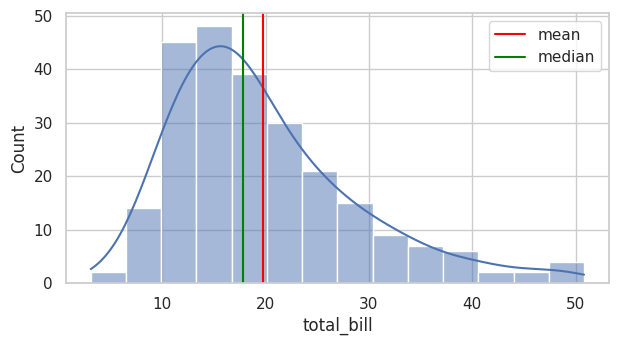

In [20]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt

 LAB EXERCISE 2 — Central tendency

1. Mean, median, mode


In [21]:
tip = df['tip']

print('Mean   :', round(tip.mean(), 2))
print('Median :', round(tip.median(), 2))
print('Mode   :', round(tip.mode()[0], 2))


Mean   : 3.0
Median : 2.9
Mode   : 2.0


2. Mean > median?


In [22]:
print('mean > median ?', tip.mean() > tip.median(), '-> right-skewed')


mean > median ? True -> right-skewed


3. Histogram with mean & median lines

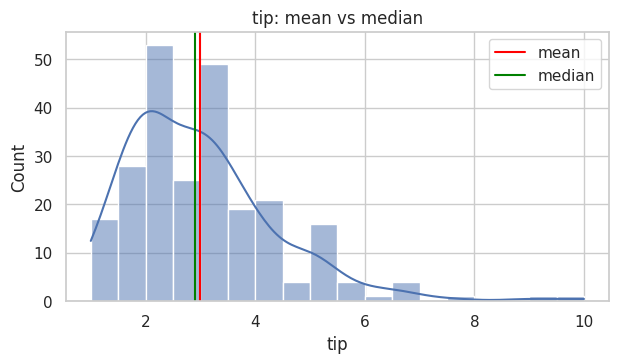

In [23]:
plt.figure(figsize=(7, 3.5))
sns.histplot(tip, kde=True)
plt.axvline(tip.mean(), color='red', label='mean')
plt.axvline(tip.median(), color='green', label='median')
plt.legend()
plt.title('tip: mean vs median')
plt.show()


3. Measures of spread (dispersion)

3A. RANGE, VARIANCE, STANDARD DEVIATION

In [24]:
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))



Range : 47.74
Var   : 79.25
Std   : 8.9


3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)

In [25]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')


Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


LAB EXERCISE 3 — Spread

1. Range, variance, standard deviation

In [26]:
tip = df['tip']

print('Range :', round(tip.max() - tip.min(), 2))
print('Var   :', round(tip.var(), 2))
print('Std   :', round(tip.std(), 2))


Range : 9.0
Var   : 1.91
Std   : 1.38


2. Q1, Q3, IQR


In [27]:
q1, q3 = tip.quantile(0.25), tip.quantile(0.75)
iqr = q3 - q1

print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2))


Q1 (25%): 2.0
Q3 (75%): 3.56
IQR     : 1.56


3. Most robust measure of spread


In [28]:
print('Most robust measure of spread = IQR because it is less affected by outliers.')


Most robust measure of spread = IQR because it is less affected by outliers.


4. Shape: five-number summary & box plot

4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)

In [29]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)


print('\nSkewness:', round(col.skew(), 3))


min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


 4B. BOX PLOT (a picture of the five-number summary)

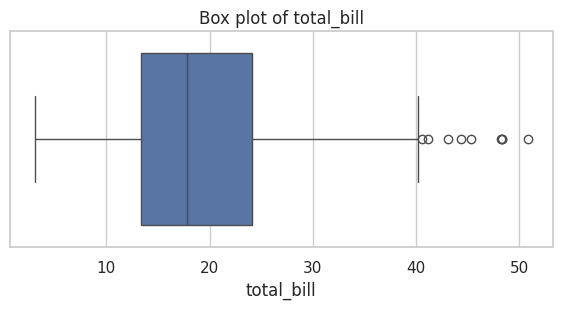

In [30]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()


LAB EXERCISE 4 — Five-number summary & box plot

1. Five-number summary


In [32]:
tip = df['tip']

five = tip.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)


min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64


2. Skewness


In [31]:
print('Skewness:', round(tip.skew(), 3))
print('The distribution leans to the right.')


Skewness: 1.465
The distribution leans to the right.


3. Box plot of tip


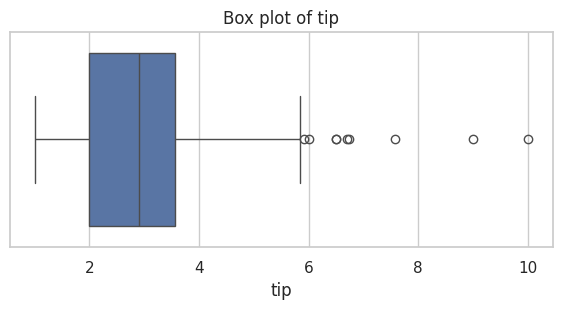

In [33]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=tip)
plt.title('Box plot of tip')
plt.show()


5. Correlation & summarizing a dataset

5A. CORRELATION between numerical columns

In [34]:
corr = df.corr(numeric_only=True)
print(corr.round(2))

print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')


            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


5B. VISUALISE THE CORRELATION MATRIX

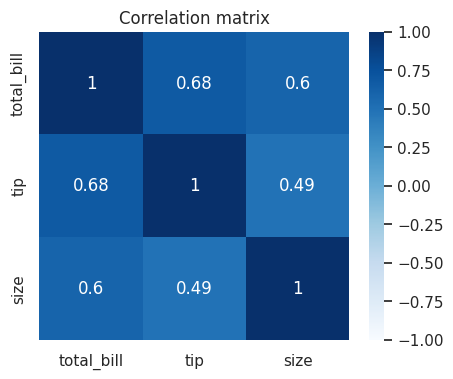

In [35]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

 5C. ONE-SHOT SUMMARY with .describe()

In [36]:
df.describe()


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


LAB EXERCISE 5 — Correlation & full summary

1. Five-number summary


In [ ]:
tip = df['tip']

five = tip.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)


2. Skewness


In [ ]:
print('Skewness:', round(tip.skew(), 3))
print('The distribution leans to the right.')


3. Box plot of tip


In [ ]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=tip)
plt.title('Box plot of tip')
plt.show()
